# Temporal Convolution Network

In this section, we generate forecasts of EEG activity using a Temporal Convolutional Network (TCN). This deep learning architecture utilizes dilated causal convolutions to capture long-range temporal dependencies and hierarchical spatial features, offering a computationally efficient method for predicting activty over short horizons.

## Background

Though convolutional networks are predominantly used for computer vision tasks such as image classification, segmentation, and generation, they have also shown promise when applied to sequence modeling tasks (e.g., speech recognition, audio synthesis and classification, etc.). In regards to time-series forecasting, TCNs serve as a powerful alternative to Recurrent Neural Networks (RNNs) because they can process long sequences in parallel rather than sequentially, significantly reducing training time while avoiding issues like vanishing gradients.

### TCN Algorithm

#### Causal Convolution
The TCN architecture relies on two fundamental principles: the network produces an output of the same length as the input, and there is no information "leakage" from the future to the past. This is achieved through the use of 1D causal convolutions, where the prediction at time $t$ is only convolved with past observations $\{X_{t-p}, \dots, X_{t-1}, X_t\}$ from the previous layer. To enforce the restriction that forecasts may only use current and past observations, the start of the input sequence is zero-padded by a length of(kernel size - 1). This padding is also added to hidden layers within the network to preserve the size of the input sequence.

Let $\mathbf{X} \in \mathbb{R}^{m \times n}$ represent activity from $m$ EEG channels over $t$ time points. Using kernel filter $\mathbf{K} \in \mathbb{R}^{m \times l}$, where $l$ is the length of the filter, a 1D causal convolution takes the form of: 

$$
\begin{align*}
(\mathbf{X} \ast \mathbf{K})(t)=\sum_{k=0}^{l-1} K_c^T \tilde{x}_{t-c} \tag{1}
\end{align*}
$$

where $x_t \in \mathbb{R}^m$ is a snapshot of activity at time $t$ and zero-padding is achieved by: 

$$
\begin{align*}
\tilde{x} = \begin{cases}
x_t & \text{if } t \ge 0 \\
0 & \text{if } t < 0
\end{cases}
\end{align*}
$$

#### Dilated Convolution

As shown in Equation (1), forecasts generated by causual convolution for timestep $t$ is only based on previous observations within the immediate window defined by kernel length $l$ (i.e., $x_{t-(l-1)}, \dots, x_{t}$). In many forecasting applications, it is important to consider a longer history of observations to sufficiently capture the underlying dynamics of a system. For example, EEG contains low-frequency oscillations that can span hundreds of time steps. While these long-range dependencies could be captured by increasing either the kernel length or the network depth, both approaches increase the number of integrated observations only linearly. This leads to a higher computational cost and a greater risk of overfitting due to the increased parameter count.

Dilated convolutions address this shortcoming by introducing a dilation factor $d$ that effectively spreads the kernel over a wider temporal area without increasing the number of trainable parameters. A $d$-dilated layer with a kernel length $l$ has a receptive field, which reflects the observations that are integrated into a forecast, of $1+d(l-1)$. A 1D dilated causal convolution takes the form of:

$$
\begin{align*}
(\mathbf{X} \ast_d \mathbf{K})(t)=\sum_{k=0}^{l-1} K_c^T \tilde{x}_{t-d \cdot c} \tag{2}
\end{align*}
$$

In practice, $d$ is typically increased exponentially with the depth of the network (e.g., $d = 2^j$ for layer $j$). This ensures that every observation within the historical window is captured by at least one filter tap, allowing the model to achieve a massive receptive field with significantly fewer layers and parameters than standard convolutional or recurrent architectures.

#### Residual Connections

As a TCN grows deeper to increase its receptive field, it encounters the vanishing gradient problem. In short, the vanishing gradient problem is when the weights in layers farther from the output layer are neglibly changed due to small gradients. A common approach to combat this issue and stabilize training is the use of residual (i.e., skip) connections. Instead of forcing a layer to learn a completely new representation from scratch, the residual connection allows the network to learn a residual mapping—essentially learning only the incremental "correction" needed to improve the current state.

A residual block takes the form of: 

$$
\begin{align*}
\mathbf{Z} = g(\mathbf{X} + \mathcal{F}(\mathbf{X}))
\end{align*}
$$

where $g$ is an activation function, $\mathbf{Z}$ is the output of a residual block, and $\mathcal{F}(\mathbf{X})$ represents a series of dilated convolutions, activations, and optional dropout layers within the block. 

# Implementing TCN

Lets see how well the TCN is able to forecast neural activity. To construct and train the network, we will use PyTorch.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import math
from tqdm import trange
import matplotlib.pyplot as plt

First, lets load the SSVEP dataset from Gu et al., 2024. In contrast to our application the the DMD and VARIMA models, we will use every trial within the dataset to train and evaluate the TCN model.

In [2]:
# load single subject from Gu et al., 2024 SSVEP experiment
# Note, data has been downsampled to 250 Hz
data = np.load('../dataset/Data/data_s1_64_down.npy')

In [3]:
# block x stimulation frequency x time x channels x conditions (i.e., modulation depths; low and high luminance ratios)
# stimulation frequencies are from 1-60 in increments of 1 Hz
nBlocks, nFreqs, nTime, nChans, nCons = data.shape

# block x stim freqs x time x channels
con_idx = 1
X = data[:, :, :, :, con_idx]

# collapse over stimulation frequencies to increase amount of data
X = X.reshape(-1, *X.shape[2:])

# transpose to make block x channels x time
X = np.swapaxes(X, 1, 2)

# SSVEPs are typically localized over the P-PO-O electrodes 
ssvep_chan_names = ['Pz', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'O1', 'Oz', 'O2']
ssvep_chans_idx = [48,54,55,56,57,58,61,62,63]

ssvep_chans_dict = dict(zip(ssvep_chan_names, ssvep_chans_idx))

In [4]:
# construct time vector. Stimulation time is 5s, and epochs included 0.14s post stimulus offset
Fs = 250.
t = np.arange(0, 5.14, 1/Fs) * 1000

Next, we are going to define a custom dataset class that is compatible with the PyTorch `DataLoader`. This will facilitate our ability to sample data during training:

In [5]:
class customDataSet(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        # sample dataset
        X = self.data[idx, :]
        return X

Now, lets define our model. First, we'll create a residual block so that we can stack multiple to create a deep network.

In [6]:
class TCNResBlock(nn.Module):
    def __init__(self, in_channels, nFilters, kernel_size, dilation, dropout=0.0):
        super().__init__()

        self.in_channels = in_channels
        padding_size = (kernel_size - 1) * dilation
        
        self.layer1 = nn.Sequential(
            nn.ZeroPad1d((padding_size, 0)), # zero-padd the input
            nn.Conv1d(                      # dilated causal convolution
                in_channels=in_channels,
                out_channels=nFilters,
                kernel_size=kernel_size,
                padding=0,
                dilation=dilation 
                ),
            nn.BatchNorm1d(nFilters),       # normalize outputs to stabilize training
            nn.ReLU(),
            nn.Dropout(p=dropout)           # optional dropout for regularization

        )

        self.layer2 = nn.Sequential(
            nn.ZeroPad1d((padding_size, 0)),
            nn.Conv1d(
                in_channels=nFilters,
                out_channels=nFilters,
                kernel_size=kernel_size,
                padding=0,
                dilation=dilation
            ),
            nn.BatchNorm1d(nFilters),
            nn.ReLU(),
            nn.Dropout(p=dropout)
        )

        self.relu = nn.ReLU()

        # Define a convolution unit with a 1x1 filter to resample a residual connection
        # in the event that the input and output sequences have different lengths
        self.resample = nn.Conv1d(
            in_channels=in_channels,
            out_channels=nFilters,
            kernel_size=1
        ) if in_channels != nFilters else None

    def forward(self, X):
        out = self.layer1(X)
        out = self.layer2(out)

        # residual connection
        res = X if self.resample is None else self.resample(X)
        out = self.relu(out + res)

        return out

Following the architecture outline in Bai et al., 2018 (Figure 1b), our residual block contains two sets of a sequence of dialted convolution, batch normaliztion, and dropout layers. An optional residual connection is used in the event that the input sequence is not equivalent to the number of convolutional filters. We can now stack these blocks to create our network.

In [21]:
class TCN(nn.Module):
    def __init__(self, input_size, horizon, nFilters, kernel_size=3, dropout=0.0):
        super(TCN, self).__init__()
        self.input_size = input_size
        self.residual_blocks = nn.ModuleList()
        in_channels = input_size[0]
        seq_length = input_size[-1]

        # approximate minimum depth required for network to cover entire input sequence
        n_residual_blocks = math.ceil(np.log2((seq_length-1)/(2*(kernel_size-1))))

        for i in range(n_residual_blocks):
            res_block = TCNResBlock(
                in_channels=in_channels,
                nFilters=nFilters,
                kernel_size=kernel_size,
                dilation=2**(i+1), # exponentially increase dilation per layer
                dropout=dropout
            )
            self.residual_blocks.append(res_block)
            in_channels=nFilters # update in_channels for the next block since output is nFilters

        # project extracted features from TCN to output dimension
        self.conv_proj = nn.Linear(in_features=seq_length, out_features=horizon)

        # project spatial dimension from nFilters to original shape
        self.spatial_proj = nn.Linear(in_features=nFilters, out_features=input_size[0])

    def forward(self, X):
        # noise augmentation
        if self.spatial_proj.training:
            X = X + torch.randn(X.size(), dtype=X.dtype, device=X.device)

        # pass input through the network
        for block in self.residual_blocks:
            X = block(X)

        # forecast
        X = self.conv_proj(X)
        X = X.swapaxes(1,2) # place spatial dimension last
        # project spatial dimension back into original size
        out = self.spatial_proj(X).swapaxes(1,2)
        
        return out

In this implementation, we stack multiple TCN residual blocks to construct the network. Rather than manually specifying the number of layers, we calculate the required depth based on the receptive field ($RF$) of the network, defined as:$$RF = 1 + 2(l - 1)(2^D - 1)$$where $l$ is the kernel length and $D$ represents the number of residual blocks. To ensure the model can "see" the entire input sequence, we determine the minimum number of blocks by solving for $D$:

$$
\begin{align*}
2^D \approx \frac{\text{input sequence length} - 1}{2(l - 1)}
\end{align*}
$$

Standard TCNs produce an output sequence equal in length to the input, which traditionally limits the forecasting horizon. To provide greater flexibility, we utilize the TCN as a feature extractor. The resulting high-dimensional temporal features are passed to linear projection layers, allowing the model to generate forecasts for any desired horizon for each channel, regardless of the initial input length.

Next, we are going to partition the data into training, validation, and test sets. While time-series data is typically split chronologically, our goal is to evaluate the model’s ability to generalize to entirely unseen EEG trials, such as how it would be employed in a brain-computer interface. To achieve this, we employ a two-tiered splitting strategy: first partitioning the data by trial, and then by time within those trials.

In [8]:
nTrials = X.shape[0]
nTestTrials = math.ceil(nTrials*0.2) # 20% test
shuffIdx = np.random.permutation(nTrials)

X_test = X[shuffIdx[-nTestTrials:], :]
X_train_val = X[shuffIdx[:-nTestTrials], :]

nValidTrials = math.ceil(X_train_val.shape[0] * 0.2) # 20% validation
X_val = X_train_val[-nValidTrials:, :]
X_train = X[:-nValidTrials, :]

In [9]:
X_test.shape, X_val.shape, X_train.shape

((144, 64, 1285), (116, 64, 1285), (604, 64, 1285))

Now we'll normalize the datasets, create their respective data loaders, and begin training:

In [10]:
X_train_mu, X_train_sd = X_train.mean(), X_train.std()

X_train = (X_train - X_train_mu) / X_train_sd
X_val = (X_val - X_train_mu) / X_train_sd
X_test = (X_test - X_train_mu) / X_train_sd

In [11]:
X_train = torch.Tensor(X_train).to(torch.float32)
X_val = torch.Tensor(X_val).to(torch.float32)
X_test = torch.Tensor(X_test).to(torch.float32)

In [12]:
train_dataset = customDataSet(X_train)
val_dataset = customDataSet(X_val)
test_dataset = customDataSet(X_test)

In [167]:
BATCH_SIZE = 64
LEARN_RATE = 1e-3
N_EPOCHS = 600
HORIZON_MS = 1000
HORIZON = abs(t-HORIZON_MS).argmin().item() + 1 # Forecast last 1000 ms
SEQ_LENGTH = nTime - HORIZON
UPDATE_FREQ = 50

In [168]:
trainDL = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valDL = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
testDL = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [169]:
device = torch.device('cuda')

In [170]:
model = TCN(
    input_size = (nChans, SEQ_LENGTH), 
    horizon=HORIZON,
    nFilters=128,
    kernel_size=125, # make equivalent to ~500 ms
).to(device)

In [171]:
optimizer = optim.NAdam(model.parameters(), lr=LEARN_RATE)
criterion = nn.MSELoss()

In [172]:
# Training loop
train_loss = []
val_loss = []
for iEpoch in trange(N_EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    for train_batch in trainDL:
        # split data chronologically to get target sequence
        input_sequence = train_batch[:, :, :-HORIZON].to(device)
        target_sequence = train_batch[:, :, -HORIZON:].to(device)

        batch_predictions = model(input_sequence)
        batch_loss = criterion(batch_predictions, target_sequence)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        epoch_train_loss += batch_loss.item()

    train_loss.append(epoch_train_loss / len(trainDL))

    # Validation
    if (iEpoch + 1) % UPDATE_FREQ == 0:
        
        model.eval()
        epoch_val_loss = 0.0

        with torch.no_grad():
            for val_batch in valDL:
                # split data chronologically to get target sequence
                input_sequence = val_batch[:, :, :-HORIZON].to(device)
                target_sequence = val_batch[:, :, -HORIZON:].to(device)

                batch_predictions = model(input_sequence)
                batch_loss = criterion(batch_predictions, target_sequence)

                epoch_val_loss += batch_loss.item()

            val_loss.append(epoch_val_loss / len(valDL))

        print(f"Epoch [{iEpoch + 1}/{N_EPOCHS}] | Train Loss: {epoch_train_loss/len(trainDL):.3e} | Val Loss: {epoch_val_loss/len(valDL):.3e}")



  8%|▊         | 50/600 [01:35<17:40,  1.93s/it]

Epoch [50/600] | Train Loss: 4.008e-01 | Val Loss: 5.048e-01


 17%|█▋        | 100/600 [03:10<16:05,  1.93s/it]

Epoch [100/600] | Train Loss: 3.306e-01 | Val Loss: 4.390e-01


 25%|██▌       | 150/600 [04:46<14:28,  1.93s/it]

...

Epoch [500/600] | Train Loss: 1.733e-01 | Val Loss: 3.245e-01


 92%|█████████▏| 550/600 [17:27<01:36,  1.93s/it]

Epoch [550/600] | Train Loss: 1.562e-01 | Val Loss: 3.078e-01


100%|██████████| 600/600 [19:02<00:00,  1.90s/it]

Epoch [600/600] | Train Loss: 1.476e-01 | Val Loss: 3.000e-01


Lets take a look at the training results and how well the model performs on the test data set

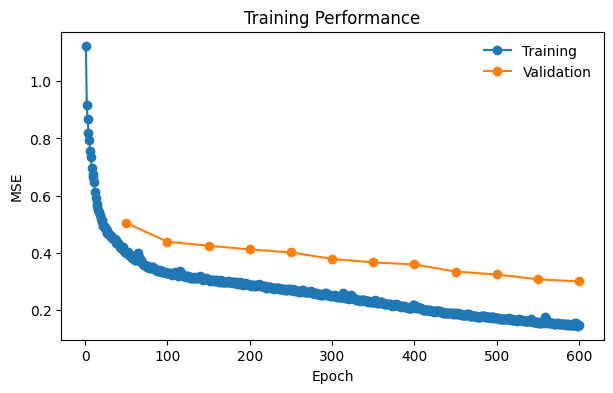

In [173]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(N_EPOCHS)+1, train_loss, marker='o', label='Training')
plt.plot(
    [x for x in np.arange(N_EPOCHS) + 1 if not x % UPDATE_FREQ],
    val_loss,
    marker='o',
    label='Validation'
)
plt.title('Training Performance')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend(frameon=False)
plt.show()

In [174]:
model.eval()
with torch.no_grad():
    input_sequence = X_test[:, :, :-HORIZON].to(device)
    target_sequence = X_test[:, :, -HORIZON:].to(device)

    predictions = model(input_sequence)
    test_loss = criterion(predictions, target_sequence)

    predictions = predictions.cpu().numpy()

print(f'Test MSE: {test_loss.item():0.3e}')

Test MSE: 4.577e-01


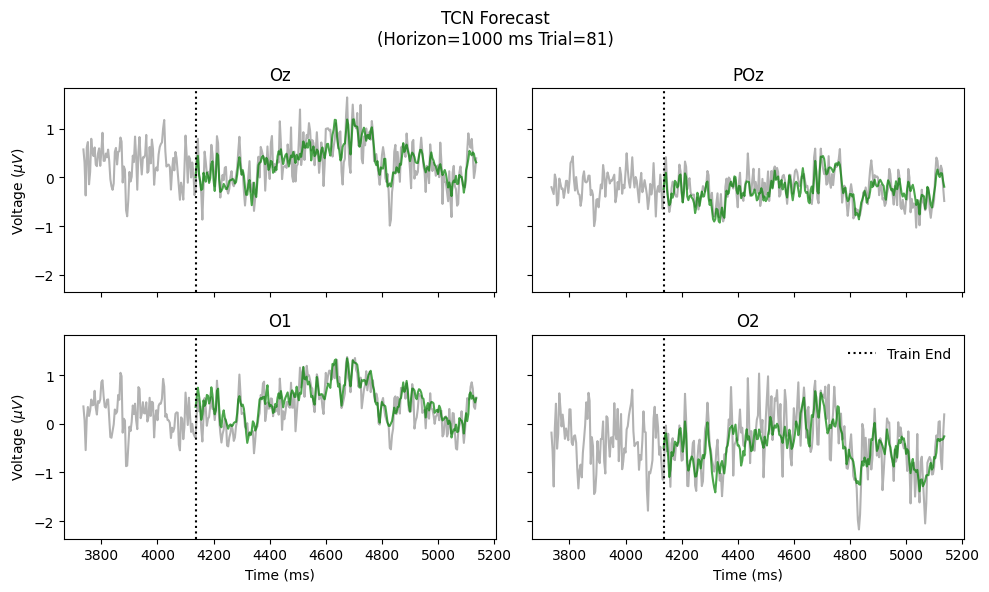

In [176]:
# Plot single trial performance
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6), dpi=100, sharex=True, sharey=True)
trial_idx = 80
time_plot_buffer = 100 # make visualization easier
axs = axs.ravel()
for i, c in enumerate(['Oz', 'POz', 'O1', 'O2']):

    axs[i].plot(t[-(HORIZON+time_plot_buffer):], X_test.cpu().numpy()[trial_idx, ssvep_chans_dict[c], -(HORIZON+time_plot_buffer):], color='k', alpha=0.3)
    axs[i].plot(t[-HORIZON:], predictions[trial_idx, ssvep_chans_dict[c], :], color='g', alpha=0.7)
    axs[i].set_title(c)
    axs[i].axvline(t[-HORIZON], color='black', linestyle=':', label='Train End')

    if i > 1:
        axs[i].set_xlabel('Time (ms)')

    if i in [0, 2]:
        axs[i].set_ylabel(r'Voltage ($\mu V$)')

    if i==3:
        axs[i].legend(frameon=False)

plt.suptitle(f'TCN Forecast\n(Horizon={HORIZON_MS} ms Trial={trial_idx+1})')
plt.tight_layout()
plt.show()